> Benjamin Nikholas

> Data Science / JCSDOL-014

> Modul 3 - Tugas 19

> 24 Juli 2024
---
---

In [1]:
import pandas as pd
pd.set_option('display.max_columns', 30)
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, KFold, cross_val_score
# from sklearn.model_selection import TimeSeriesSplit
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, RobustScaler
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier, export_text

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

Target: 'alive'

In [76]:
df = pd.read_csv('titanic.csv')
df.info()
df.head(5)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   sex          891 non-null    object 
 1   age          714 non-null    float64
 2   parch        891 non-null    int64  
 3   fare         891 non-null    float64
 4   class        891 non-null    object 
 5   deck         203 non-null    object 
 6   embark_town  889 non-null    object 
 7   alive        891 non-null    object 
 8   alone        891 non-null    bool   
dtypes: bool(1), float64(2), int64(1), object(5)
memory usage: 56.7+ KB


,sex,age,parch,fare,class,deck,embark_town,alive,alone
0,male,22.0,0,7.2500,Third,NaN,Southampton,no,False
1,female,38.0,0,71.2833,First,C,Cherbourg,yes,False
2,female,26.0,0,7.9250,Third,NaN,Southampton,yes,True
3,female,35.0,0,53.1000,First,C,Southampton,yes,False
4,male,35.0,0,8.0500,Third,NaN,Southampton,no,True


Skema pre-processing: 
- Drop feature 'deck' 
- Isi missing value 'age' dengan simple imputer median 
- Isi missing value 'embark town' dengan simple imputer modus 
- One hot encoding: 'sex', 'embark town', 'alone'  
- Ordinal encoding: 'class' 
- Scaling dengan RobustScaler()  

In [77]:
# Drop 'deck'
df.drop(columns = ['deck'], inplace = True)

num_features = ['age', 'fare']
categorical_features = ['sex', 'embark_town', 'alone']
ordinal_features = ['class']

# Fill value 'age' with median
num_transformer = Pipeline(steps = [
    ('imputer', SimpleImputer(strategy = 'median')),
    ('scaler', RobustScaler())
])

# Fill value 'embark' with mode
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy = 'most_frequent')),
    
    # One Hot Encode : 'sex', 'embark town', 'alone'
    ('onehot', OneHotEncoder(handle_unknown = 'ignore'))
])


# Ordinal Encode : 'class'
ordinal_transformer = Pipeline(steps = [
    ('ordinal_encoder', OrdinalEncoder(categories = [['Third', 
                                                      'Second', 
                                                      'First']])),
    
    # Robust Scaller
    ('scaler', RobustScaler())
])

preprocessor = ColumnTransformer(
    transformers = [
        ('num', num_transformer, num_features),
        ('cat', categorical_transformer, categorical_features),
        ('ord', ordinal_transformer, ordinal_features)
    ])

# preprocessing
data_processed = preprocessor.fit_transform(df)

feature_names = (
    num_features +
    list(preprocessor.named_transformers_['cat'].named_steps['onehot'].get_feature_names_out(categorical_features)) +
    ordinal_features
)

data_processed_df = pd.DataFrame(data_processed, columns = feature_names)

display(data_processed_df.head())
display(data_processed_df.info())

,age,fare,sex_female,sex_male,embark_town_Cherbourg,embark_town_Queenstown,embark_town_Southampton,alone_False,alone_True,class
0,-0.461538,-0.312011,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0
1,0.769231,2.461242,1.0,0.0,1.0,0.0,0.0,1.0,0.0,2.0
2,-0.153846,-0.282777,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
3,0.538462,1.673732,1.0,0.0,0.0,0.0,1.0,1.0,0.0,2.0
4,0.538462,-0.277363,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 10 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   age                      891 non-null    float64
 1   fare                     891 non-null    float64
 2   sex_female               891 non-null    float64
 3   sex_male                 891 non-null    float64
 4   embark_town_Cherbourg    891 non-null    float64
 5   embark_town_Queenstown   891 non-null    float64
 6   embark_town_Southampton  891 non-null    float64
 7   alone_False              891 non-null    float64
 8   alone_True               891 non-null    float64
 9   class                    891 non-null    float64
dtypes: float64(10)
memory usage: 69.7 KB


None

In [78]:
exclude_cols = [num_features, categorical_features, ordinal_features]
flattened_list = np.concatenate(exclude_cols).tolist()
print(flattened_list)

include_cols = list(set(df.columns) - set(flattened_list))
print(include_cols)

df_concat = pd.concat([df[include_cols], data_processed_df], axis = 1)
df_concat.replace({'no' : 0,
                   'yes': 1},
                  inplace = True)

display(df_concat.info())
display(df_concat.head())

['age', 'fare', 'sex', 'embark_town', 'alone', 'class']
['parch', 'alive']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   parch                    891 non-null    int64  
 1   alive                    891 non-null    int64  
 2   age                      891 non-null    float64
 3   fare                     891 non-null    float64
 4   sex_female               891 non-null    float64
 5   sex_male                 891 non-null    float64
 6   embark_town_Cherbourg    891 non-null    float64
 7   embark_town_Queenstown   891 non-null    float64
 8   embark_town_Southampton  891 non-null    float64
 9   alone_False              891 non-null    float64
 10  alone_True               891 non-null    float64
 11  class                    891 non-null    float64
dtypes: float64(10), int64(2)
memory usage: 83.7 KB


None

,parch,alive,age,fare,sex_female,sex_male,embark_town_Cherbourg,embark_town_Queenstown,embark_town_Southampton,alone_False,alone_True,class
0,0,0,-0.461538,-0.312011,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0
1,0,1,0.769231,2.461242,1.0,0.0,1.0,0.0,0.0,1.0,0.0,2.0
2,0,1,-0.153846,-0.282777,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
3,0,1,0.538462,1.673732,1.0,0.0,0.0,0.0,1.0,1.0,0.0,2.0
4,0,0,0.538462,-0.277363,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0


Split data menjadi 80:20 dengan random_state = 0. 

In [79]:
X = df_concat.drop(columns = ['alive'])
y = df_concat['alive']

In [80]:
X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                    train_size = 0.8,
                                                    random_state = 0)

Tentukan metric evaluasi yang sesuai untuk kasus Titanic

Untuk kasus titanic, metrik yang akan digunakan adalah `accuracy`, `precision`, `recall`, dan `F1 Score`

Pilih model terbaik dengan cross-validation (n_splits=5): 
- Logistic regression: solver = liblinear 
- KNN: n_neighbors = 3 
- Decision tree: max depth = 3 

In [94]:
lr_model = LogisticRegression(solver = 'liblinear')
knn_model = KNeighborsClassifier(n_neighbors = 3)
dt_model = DecisionTreeClassifier(max_depth = 3)

kf = KFold(n_splits = 5, 
           shuffle = True, 
           random_state = 42)

models = [lr_model, knn_model, dt_model]

models = {
    'Logistic Regression': LogisticRegression(solver='liblinear'),
    'KNN': KNeighborsClassifier(n_neighbors=3),
    'Decision Tree': DecisionTreeClassifier(max_depth=3)
}

In [120]:
model_mean_metrics = {}
model_dict = {}
idxs = ['accuracy', 'precision', 'recall', 'f1_score']

# for model in models:
for model_name, model in models.items():

    temp_dict = {}
    
    for len, (train_index, test_index) in enumerate(kf.split(X_train)):
        X_train_fold, X_test_fold = X_train.iloc[train_index], X_train.iloc[test_index]
        y_train_fold, y_test_fold = y_train.iloc[train_index], y_train.iloc[test_index]
        
        model.fit(X_train_fold, y_train_fold)
        y_pred_fold = model.predict(X_test_fold)
        
        accuracy = accuracy_score(y_test_fold, y_pred_fold)
        precision = precision_score(y_test_fold, y_pred_fold)
        recall = recall_score(y_test_fold, y_pred_fold)
        f1 = f1_score(y_test_fold, y_pred_fold)
        
        temp_dict[f'fold-{len+1}'] = [accuracy, precision, recall, f1]

    temp_df = pd.DataFrame(temp_dict, index = idxs).T.round(3)
    model_dict[model_name] = temp_df
    # display(temp_df)
    
    temp_list = []
    for i, vals in temp_df.items():
        # print(i, vals.mean().round(3))
        temp_list.append(vals.mean().round(3))
    
    model_mean_metrics[model_name] = temp_list

model_mean_metrics = pd.DataFrame(model_mean_metrics, index = idxs)

Interpretasikan hasil metric yang dipilih tersebut.

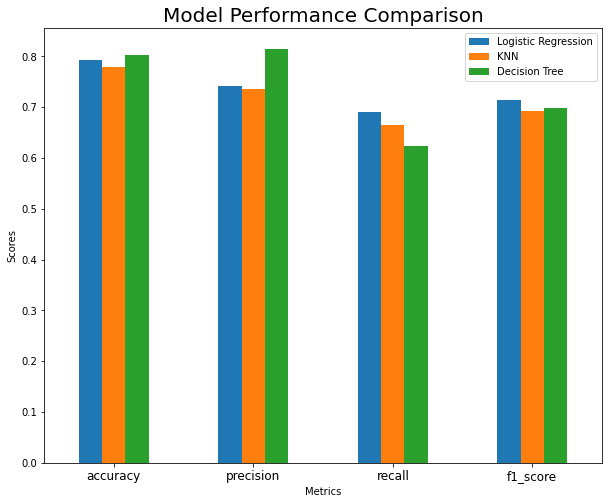

In [151]:
model_mean_metrics.plot(kind = 'bar',
                        figsize = (10, 8))

plt.xlabel('Metrics')
plt.xticks(rotation = 0, fontsize = 12)
plt.ylabel('Scores')
plt.title('Model Performance Comparison', fontsize = 20)
plt.legend()

plt.show()

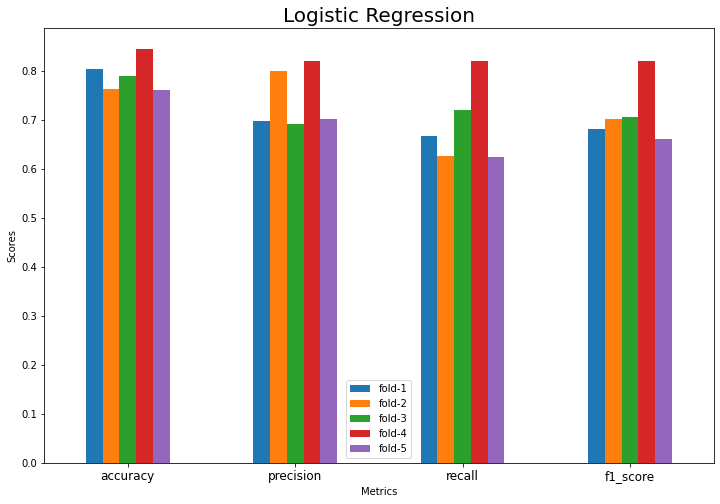

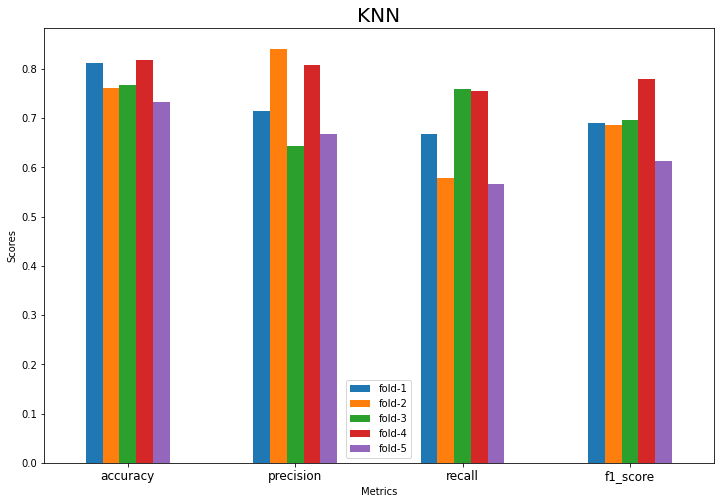

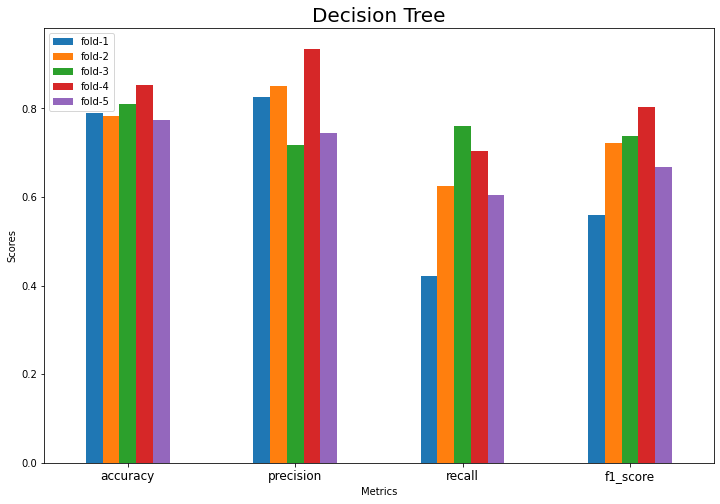

In [161]:
for model_name, model_df in model_dict.items():
    model_df.T.plot(kind = 'bar', figsize = (12, 8))

    plt.xlabel('Metrics')
    plt.xticks(rotation = 0, fontsize = 12)
    plt.ylabel('Scores')
    plt.title(model_name , fontsize = 20)
    plt.legend()

    plt.show()